In [366]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

In [367]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_mistralai import ChatMistralAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.tools.tavily_search import  TavilySearchResults
from typing import TypedDict, List, Dict, Literal
from pydantic import BaseModel,Field

import asyncio
from dotenv import load_dotenv


from src.retriever.hybrid_retriever import HybridRetriever, qdrant_client
from src.retriever.reranker import reranker, get_reranked_documents




In [368]:
load_dotenv()


True

In [369]:
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
grading_llm = ChatGroq(model = "openai/gpt-oss-20b",temperature=0)
rewriter_llm = ChatGroq(model = "llama-3.1-8b-instant",temperature=0)
router_llm = ChatGroq(model = "openai/gpt-oss-20b",temperature=0)
# llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)
# llm = ChatMistralAI(model="mistral-large-2512",temperature=0)


In [370]:
# initialize the searcher
searcher = HybridRetriever(collection_name="main_vector_store",
                            qdrant_client = qdrant_client)
search_tool = TavilySearchResults(k=5)



In [371]:

# define the state
class RagState(TypedDict):
    query: str
    document_id: str 

    retrieved_results : List[Dict]
    reranked_results : List[Dict]

    route : str
    documents_relevant : bool

    answer : str 
    
    retry_count : int 

    web_search_used : bool
    web_context : str

In [372]:
# -> Query routing node 
class QueryRoute(BaseModel):
    route : Literal[
        "direct_llm",
        "retrieve",
        "web_search"
    ]

router_prompt = ChatPromptTemplate.from_template(
    """
     You are a Query Router for a RAG system.
    Decide how the system should answer the query.

    Choose "direct_llm" ONLY for purely general knowledge questions.

    Otherwise always choose "retrieve" for all the questions.
    Question:
    {query}
    """
)

structured_router_llm = router_llm.with_structured_output(QueryRoute)

router_chain = router_prompt | structured_router_llm

In [373]:
# query router node
async def query_router_node(state : RagState):
    query = state['query']

    result = await router_chain.ainvoke({
        "query":query
    })
    return {"route" : result.route}

In [374]:
# conditional fn for query routing
def decide_query_routing(state:RagState):
    
    return state['route']


In [375]:
# direct generation node only used when query routes to direct_llm call
async def direct_generate_node(state : RagState):
    query = state['query']
    result = await llm.ainvoke(query)
    return {'answer':result.content}

In [376]:
# -> Retriever node
async def retriever_node(state: RagState):
    query = state['query']
    results = await asyncio.to_thread(searcher.search, query_text=query)
    return {'retrieved_results': results}

In [377]:
# -> Reranker node
async def reranker_node(state: RagState):
    query = state['query']
    retrieved_results = state['retrieved_results']
    reranked_results = await asyncio.to_thread(
        get_reranked_documents, query=query, retrieved_results=retrieved_results, top_k=3)
    return {'reranked_results': reranked_results}

In [378]:
#  -> Grader

class GradeDocuments(BaseModel):
    relevant: bool = Field(
        description = "Whether the retrieved context is relevant to answer the question"
    )


grader_prompt = ChatPromptTemplate.from_template("""
You are a retrieval relevance evaluator.

Your task:
Determine whether the retrieved context contains information useful
for answering the user's question.

Question:
{query}

Retrieved Context:
{context}

Rules:
- Return relevant=true if the context contains useful information
- Return relevant=false if the context is unrelated
- Be strict
""")

structured_grading_llm = grading_llm.with_structured_output(GradeDocuments)

grader_chain = grader_prompt | structured_grading_llm

In [379]:
# -> Grader node 
async def grade_documents_node(state : RagState):
    query = state['query']

    docs = state['reranked_results']

    context = "\n".join(
        doc['document'] for doc in docs 
    )

    result = await grader_chain.ainvoke({
        "query":query,
        "context":context
    })

    return {"documents_relevant":result.relevant}

In [380]:
# conditional edge
async def decide_next_step(state : RagState):
    if state['documents_relevant'] :
        return "generate_answer"
    return "transform_query"

In [381]:
# -> Query Transformer
rewrite_prompt = ChatPromptTemplate.from_template(
    """
    Rewrite the user's query to improve document retrieval.

    Original Query:
    {query}

    Return ONLY the rewritten query.
    """ 
)

rewriter_chain = rewrite_prompt | rewriter_llm

In [382]:
# query transformer node 
async def transform_query_node(state : RagState):
    current_retry = state.get('retry_count',0)
    rewritten_query = await rewriter_chain.ainvoke({
        "query":state['query']
    })
    return {
        "query":rewritten_query.content,
        "retry_count":current_retry +  1
    }

In [383]:
# connecting rewrite to retriever / web_search
async def route_after_transform(state: RagState):
    if state['retry_count'] <= 2:
        return "retriever"
    return "web_search"

In [384]:
# web search node
async def web_search_node(state:RagState):
    results = await search_tool.ainvoke(state['query'])

    web_context = "\n\n".join(
        result['content'] for result in results
    )
    return {
        "web_search_used":True,
        "web_context" : web_context
    }

In [385]:
prompt_template = ChatPromptTemplate([
    (
        "system",
        """
        You are a highly accurate RAG AI assistant.

        Your job is to answer ONLY from the provided context.

        STRICT RULES:
        1. Do NOT use outside knowledge.
        2. If the answer is not present in the context, say:
        "I could not find the answer in the provided document."
        3. Every answer MUST include citations using page numbers, source and title.
        4. If information comes from multiple pages, cite all relevant pages.
        5. At the end, provide a confidence level:
        - HIGH → answer clearly supported by context
        - MEDIUM → partially supported or inferred from context
        - LOW → weak evidence or incomplete information
        6. Keep answers concise, factual, and grounded.
        7. Never hallucinate page numbers or facts.
        8. If page numbers,source or title are unavailable in context metadata, say:
        "<Page number / Source / Title> not available."

        RESPONSE FORMAT:

        Answer:
        <your answer>

        Citations:
        <title>
        <Page 3>
        <Page 5, Page 8>

        Confidence:
        <HIGH / MEDIUM / LOW>
        """
    ),
    (
        "human",
        """
        Context:
        {context}

        Question:
        {query}
        """
    )
])
async def generate_answer_node(state: RagState):
    query = state['query']
    if state.get("web_search_used"):
        context = state['web_context']
    else:
        context = state['reranked_results']
        context = context = "\n".join(
            f"""
            Source: {chunk['metadata'].get('file_name')}
            Page: {chunk['metadata'].get('page')}
            Content:
            {chunk['document']}
            """
            for chunk in context
        )
    final_prompt = prompt_template.invoke({
        "query":query,
        "context":context
    })
    response = await llm.ainvoke(final_prompt)
    return {
        "answer":response.content
    }
        

In [386]:
# build the graph

graph = StateGraph(RagState)

# nodes of the graph
graph.add_node("query_router",query_router_node)
graph.add_node("direct_generation",direct_generate_node)
graph.add_node("retriever",retriever_node)
graph.add_node("reranker",reranker_node)
graph.add_node("grade_documents",grade_documents_node)
graph.add_node("generate_answer",generate_answer_node)
graph.add_node("transform_query",transform_query_node)
graph.add_node("web_search",web_search_node)

# edges of the graph
graph.add_edge(START,"query_router")

graph.add_conditional_edges(
    "query_router",
    decide_query_routing,
    {
        "direct_llm":"direct_generation",
        "retrieve": "retriever"

    }
)

graph.add_edge("retriever","reranker")

graph.add_edge("reranker","grade_documents")

graph.add_conditional_edges(
    "grade_documents",
    decide_next_step,
    {
        "generate_answer":"generate_answer",
        "transform_query":"transform_query"
    }
)

graph.add_conditional_edges(
    "transform_query",
    route_after_transform,
    {
        "retriever":"retriever",
        "web_search":"web_search"
    }
)

graph.add_edge("web_search","generate_answer")

graph.add_edge("direct_generation",END)

graph.add_edge("generate_answer",END)

In [387]:
workflow = graph.compile()

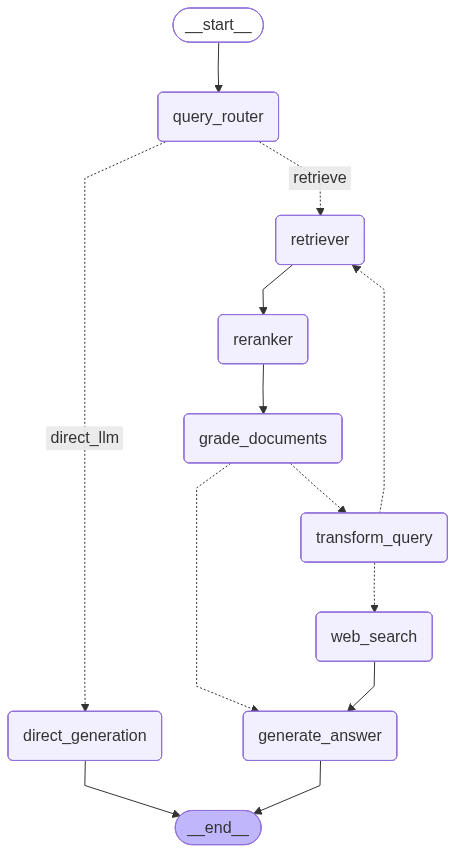

In [388]:
workflow

In [389]:
final_state = await workflow.ainvoke({
   "query":"What is the current gold price in India ?"
})

In [390]:
final_state

{'query': '"Current gold price in India as of 28 May 2024"',
 'retrieved_results': [{'score': 0.5,
   'payload': {'document_id': 'cb6a3e5a-5571-4fb7-9d21-b8990e9c2602',
    'file_name': 'GRU.pdf',
    'text': 'Schuster, Mike and Paliwal, Kuldip K. Bidirectional re-\ncurrent neural networks. IEEE transactions on Signal\nProcessing, 45(11):2673–2681, 1997.\nSmagulova, Kamilya and James, Alex Pappachen. A sur-\nvey on LSTM memristive neural network architectures\nand applications. The European Physical Journal Spe-\ncial Topics, 228(10):2313–2324, 2019.\nStaudemeyer, Ralf C and Morris, Eric Rothstein.\nUn-\nderstanding LSTM–a tutorial into long short-term\nmemory recurrent neural networks.\narXiv preprint',
    'page': 14,
    'title': 'Recurrent Neural Networks and Long Short-Term Memory Networks: Tutorial and Survey'}},
  {'score': 0.5,
   'payload': {'document_id': '2f87e44b-ad36-44fa-8864-648f3e1b3521',
    'file_name': 'Meridian_BioSciences_Annual_Report_FY2024.pdf',
    'text': '\u2

In [391]:
print(final_state['answer'])

Answer:
The current gold price in India as of 28 May 2024 is: 
- 22K gold: Rs 66,850/10 grams, 
- 24K gold: Rs 72,930/10 grams, 
- 18K gold: Rs 54,700/10 grams.

Citations:
GoodReturns, 
Page not available.

Confidence:
HIGH
